<a href="https://colab.research.google.com/github/Gafinhords/Just-a-test-repository/blob/main/FIFA2021_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aayushmishra1512/fifa-2021-complete-player-data")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'fifa-2021-complete-player-data' dataset.
Path to dataset files: /kaggle/input/fifa-2021-complete-player-data


In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/aayushmishra1512/fifa-2021-complete-player-data/versions/1/FIFA-21 Complete.csv', sep=';')
df.head()

,player_id,name,nationality,position,overall,age,hits,potential,team
0,158023,Lionel Messi,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona
1,20801,Cristiano Ronaldo,Portugal,ST|LW,93,35,276,93,Juventus
2,190871,Neymar Jr,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain
3,203376,Virgil van Dijk,Netherlands,CB,91,29,127,92,Liverpool
4,200389,Jan Oblak,Slovenia,GK,91,27,47,93,Atlético Madrid


In [ ]:
df = df.drop('player_id', axis=1)
df.head()

,name,nationality,position,overall,age,hits,potential,team
0,Lionel Messi,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona
1,Cristiano Ronaldo,Portugal,ST|LW,93,35,276,93,Juventus
2,Neymar Jr,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain
3,Virgil van Dijk,Netherlands,CB,91,29,127,92,Liverpool
4,Jan Oblak,Slovenia,GK,91,27,47,93,Atlético Madrid


In [ ]:
df = df.drop('name', axis=1)
df.head()

,nationality,position,overall,age,hits,potential,team
0,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona
1,Portugal,ST|LW,93,35,276,93,Juventus
2,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain
3,Netherlands,CB,91,29,127,92,Liverpool
4,Slovenia,GK,91,27,47,93,Atlético Madrid


In [ ]:
df.describe()

,overall,age,hits,potential
count,17981.000000,17981.000000,17981.000000,17981.000000
mean,67.274345,26.311440,2.689450,71.738057
std,5.924392,4.556077,10.846286,5.961968
min,56.000000,17.000000,0.000000,57.000000
25%,63.000000,23.000000,0.000000,67.000000
50%,67.000000,26.000000,0.000000,71.000000
75%,71.000000,30.000000,2.000000,76.000000
max,94.000000,43.000000,371.000000,95.000000


Будем предсказывать рейтинг игрока(overall) на основании его ПРИ(Потенциальный Рост Игрока), возрасте, позиции, по кол-ву его ударов, а также проверим как коррелируют команды с рейтингом и национальность игрока с его рейтингом. Зачем мы будем проверять коррелицию национальности/рейтинга и команды/рейтинга - в разных странах разная футбольная культура и разные футбольне школы и игровые стили, это ключевым образом влияет на результативность игрока, а в команде есть такие факторы как: хорошее взаимодействие с другими игроками, качество тренера, дают ли игроки раскрыть потенциал молодого таланта и есть ли здоровая конкуренция и наставничество в клубе

<Axes: xlabel='potential', ylabel='overall'>

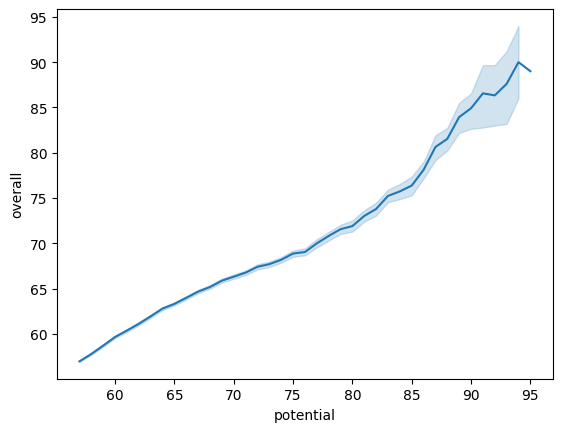

In [ ]:
sns.lineplot(data=df, x='potential', y='overall')

Как мы видим зависимость рейтинга игрока от его ПРИ почти линейная, но ПРИ является продуктом аналитической деятельности других людей и не является параметром, взятым из наблюдения. Моим предложением и решением будет исколючить ПРИ из финального анализа и данных, на которых будет обучаться модель, но проверить корреляцию ПРИ с другими данными необходимо и интересно

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['team_code'] = le.fit_transform(df['team'])
df.head()

,nationality,position,overall,age,hits,potential,team,team_code
0,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona,243
1,Portugal,ST|LW,93,35,276,93,Juventus,375
2,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain,487
3,Netherlands,CB,91,29,127,92,Liverpool,417
4,Slovenia,GK,91,27,47,93,Atlético Madrid,64


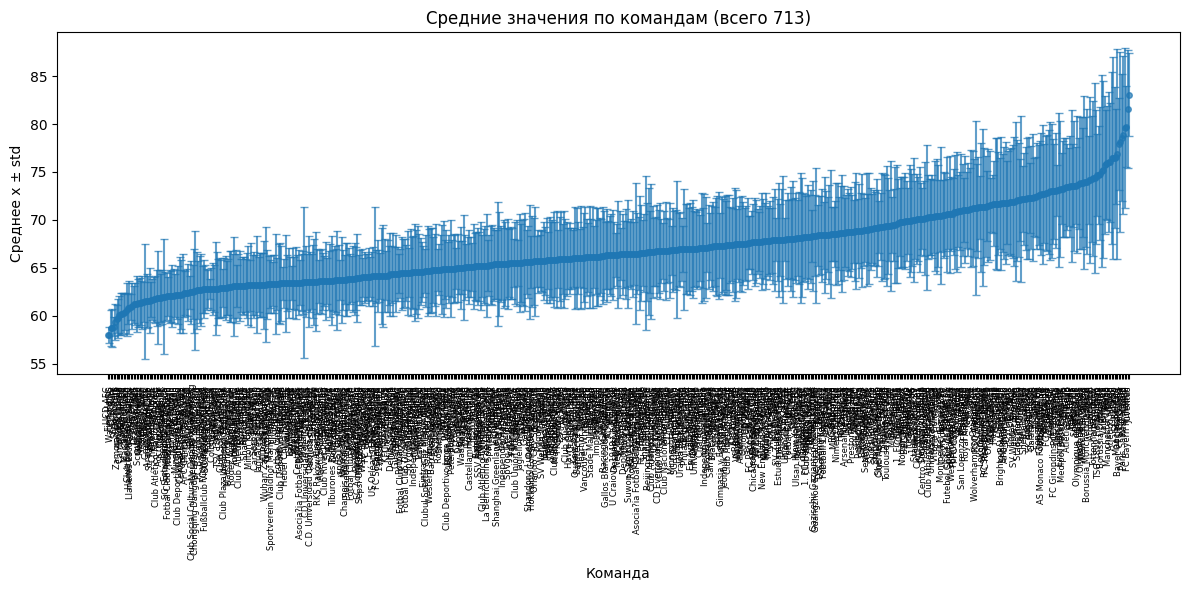

In [ ]:
stats = df.groupby('team')['overall'].agg(['mean', 'std', 'count']).reset_index()
stats = stats.sort_values('mean')  # сортируем для лучшей читаемости

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(stats)), stats['mean'], yerr=stats['std'],
             fmt='o', capsize=3, alpha=0.7, markersize=4)
plt.xticks(range(len(stats)), stats['team'], rotation=90, fontsize=6)
plt.xlabel('Команда')
plt.ylabel('Среднее x ± std')
plt.title('Средние значения по командам (всего {})'.format(len(stats)))
plt.tight_layout()
plt.show()

Единственное что могу сказать, что в наиболее сильных командах сосредоточено наибольшее кол-во игроков с высоким рейтингом. Давайте теперь проверим команда/ПРИ

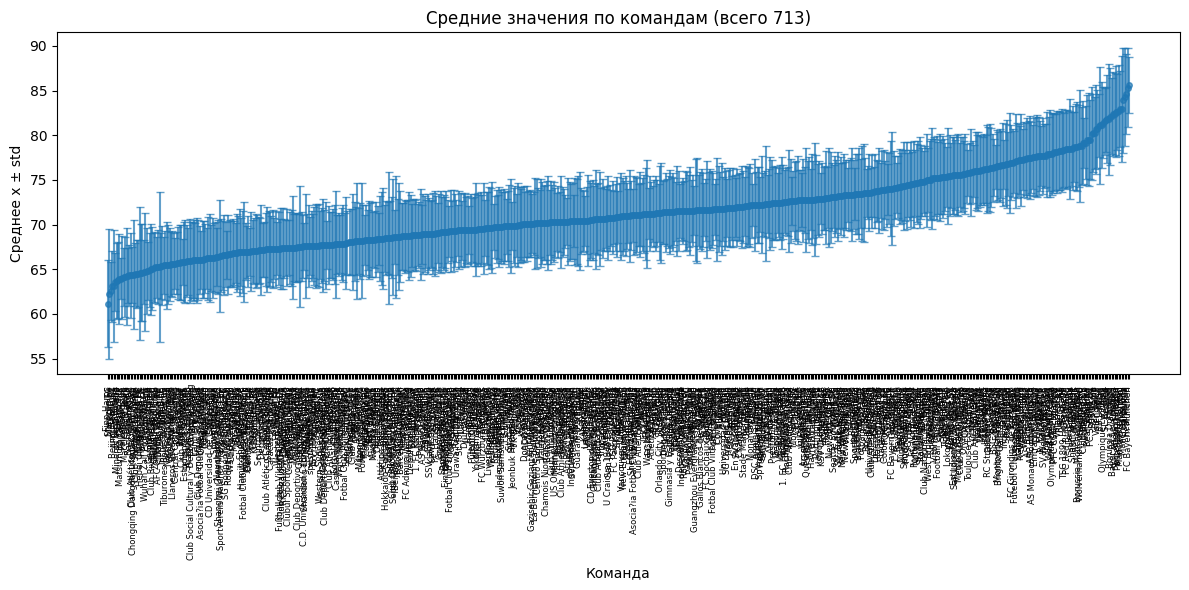

In [ ]:
stats = df.groupby('team')['potential'].agg(['mean', 'std', 'count']).reset_index()
stats = stats.sort_values('mean')  # сортируем для лучшей читаемости

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(stats)), stats['mean'], yerr=stats['std'],
             fmt='o', capsize=3, alpha=0.7, markersize=4)
plt.xticks(range(len(stats)), stats['team'], rotation=90, fontsize=6)
plt.xlabel('Команда')
plt.ylabel('Среднее x ± std')
plt.title('Средние значения по командам (всего {})'.format(len(stats)))
plt.tight_layout()
plt.show()

Графики +- совпадают, следовательно могу сказать, что команда тоже влияет на рейтинг и ПРИ. Теперь проверим зависимость рейтинга от страны

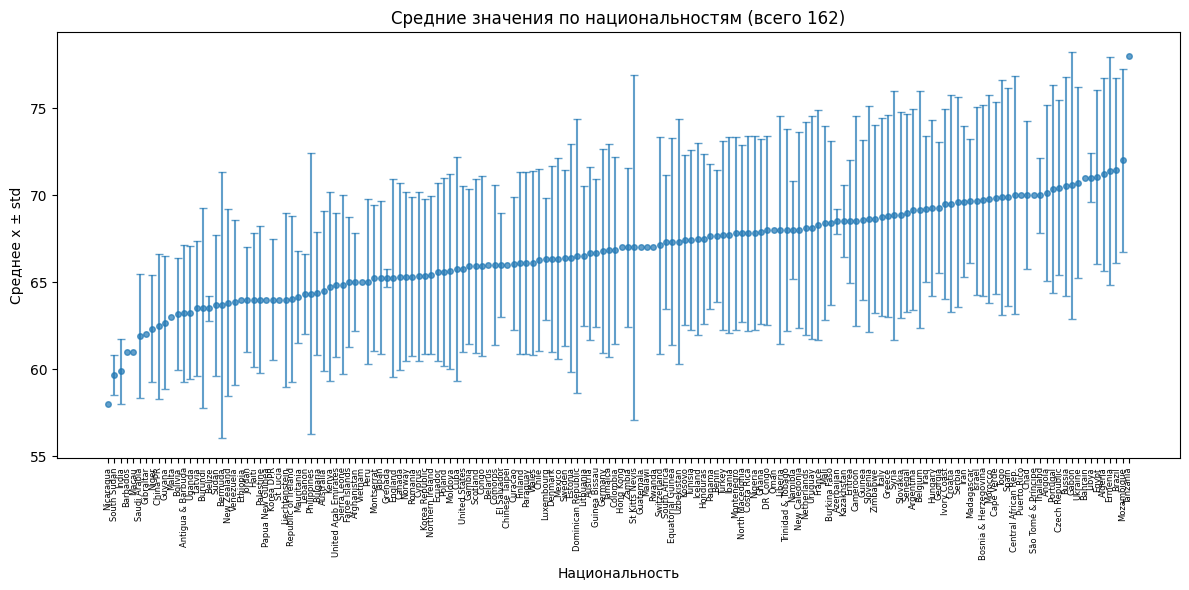

In [ ]:
stats = df.groupby('nationality')['overall'].agg(['mean', 'std', 'count']).reset_index()
stats = stats.sort_values('mean')  # сортируем для лучшей читаемости

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(stats)), stats['mean'], yerr=stats['std'],
             fmt='o', capsize=3, alpha=0.7, markersize=4)
plt.xticks(range(len(stats)), stats['nationality'], rotation=90, fontsize=6)
plt.xlabel('Национальность')
plt.ylabel('Среднее x ± std')
plt.title('Средние значения по национальностям (всего {})'.format(len(stats)))
plt.tight_layout()
plt.show()

График медленно возрастающий, следовательно национальность тоже влияет на рейтинг игрока

In [ ]:
df.head()

,nationality,position,overall,age,hits,potential,team
0,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona
1,Portugal,ST|LW,93,35,276,93,Juventus
2,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain
3,Netherlands,CB,91,29,127,92,Liverpool
4,Slovenia,GK,91,27,47,93,Atlético Madrid


In [ ]:
df['position_cleaned'] = df['position'].str.split('|')
df_exploded = df.explode('position_cleaned')
df_exploded = df_exploded.rename(columns={'position_cleaned': 'position'})
df.head()

,nationality,position,overall,age,hits,potential,team,position_cleaned
0,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona,"[ST, CF, RW]"
1,Portugal,ST|LW,93,35,276,93,Juventus,"[ST, LW]"
2,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain,"[CAM, LW]"
3,Netherlands,CB,91,29,127,92,Liverpool,[CB]
4,Slovenia,GK,91,27,47,93,Atlético Madrid,[GK]


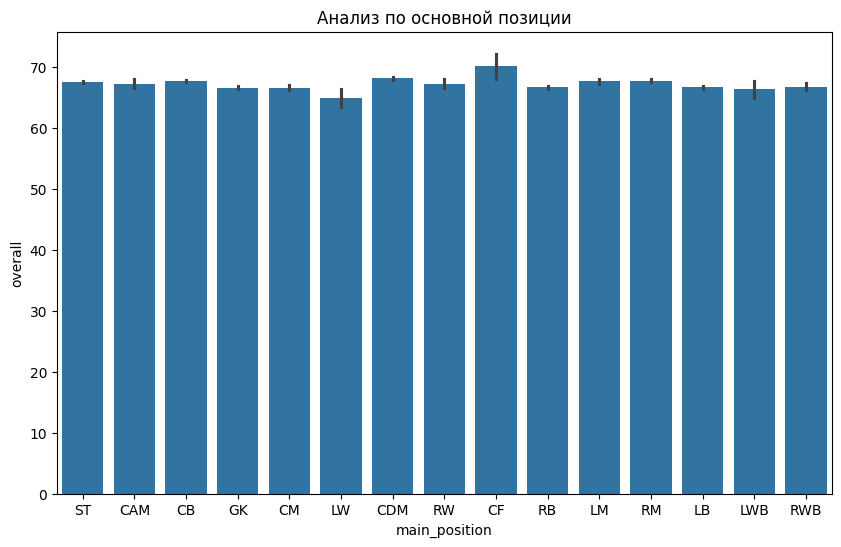

In [ ]:
df['main_position'] = df['position'].str.split('|').str[0]

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='main_position', y='overall')
plt.title('Анализ по основной позиции')
plt.show()

Зависимость рейтинга от позиции не показало какой-либо закономерности, что было ожидаемо, соответственно эту строку можно выключить из финального анализа

In [ ]:
df.head()

,nationality,overall,age,hits,potential,team
0,Argentina,94,33,299,94,FC Barcelona
1,Portugal,93,35,276,93,Juventus
2,Brazil,92,28,186,92,Paris Saint-Germain
3,Netherlands,91,29,127,92,Liverpool
4,Slovenia,91,27,47,93,Atlético Madrid


In [ ]:
df = df.drop('position', axis=1)

Проанализируем зависимость кол-ва ударов от рейтинга

<Axes: xlabel='overall', ylabel='hits'>

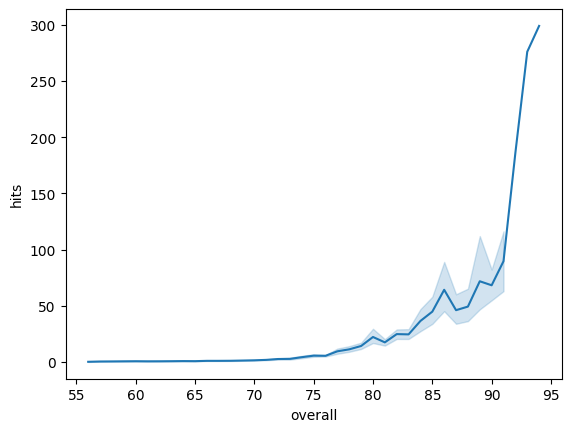

In [ ]:
sns.lineplot(data=df, x='overall', y='hits')

Кол-во ударов от рейтинга имеет экспоненциально-возрастающую зависимость

In [ ]:
X = df.drop('overall', axis=1)
y = df['overall']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.head()

,nationality,age,hits,potential,team
12414,England,23,0,70,Walsall
13780,England,25,0,67,Stevenage
6790,Venezuela,33,0,69,KV Oostende
4789,Scotland,28,0,71,Norwich City
7061,Spain,30,0,68,AD Alcorcón


In [ ]:
def target_encoding_correct(X_train, X_test, categorical_col, y_train, smooth=20):
    # Обучаемся ТОЛЬКО на train
    global_mean = y_train.mean()
    cat_stats = X_train.groupby(categorical_col)[y_train.name].agg(['mean', 'count'])
    cat_stats['encoded'] = (cat_stats['mean'] * cat_stats['count'] +
                            global_mean * smooth) / (cat_stats['count'] + smooth)

    # Применяем к train и test
    X_train[f'{categorical_col}_encoded'] = X_train[categorical_col].map(cat_stats['encoded'])
    X_test[f'{categorical_col}_encoded'] = X_test[categorical_col].map(cat_stats['encoded'])

    # Новые категории в test - заполняем глобальным средним
    X_test[f'{categorical_col}_encoded'].fillna(global_mean, inplace=True)

    return X_train, X_test

In [ ]:

X_test.head()

,nationality,age,hits,potential,team
5954,Israel,26,1,72,Sporting Kansas City
2616,Brazil,31,3,74,Shakhtar Donetsk
4518,Morocco,31,2,71,Denizlispor
4400,Korea Republic,28,4,71,Sangju Sangmu FC
13816,Norway,26,0,66,Lillestrøm SK


In [ ]:
df.head()

,nationality,overall,age,hits,potential,team
0,Argentina,94,33,299,94,FC Barcelona
1,Portugal,93,35,276,93,Juventus
2,Brazil,92,28,186,92,Paris Saint-Germain
3,Netherlands,91,29,127,92,Liverpool
4,Slovenia,91,27,47,93,Atlético Madrid


In [ ]:
X_train, X_test = target_encoding_correct(X_train, X_test, 'nationality', y_train, smooth=20)
X_train, X_test =target_encoding_correct(X_train, X_test, 'team', y_train, smooth=50)

KeyError: 'Column not found: overall'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Разделяем на признаки и целевую переменную
X = df.drop('overall', axis=1)
y = df['overall']

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмеры:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Функция target encoding
def target_encoding_safe(X_train, X_test, y_train, categorical_col, smooth=20):
    """
    X_train, X_test - признаки (DataFrame)
    y_train - целевая переменная (Series)
    categorical_col - название колонки с категориями
    smooth - параметр сглаживания
    """
    # Создаем временный DataFrame
    temp_df = X_train.copy()
    temp_df['target'] = y_train.values

    # Статистика по категориям
    category_stats = temp_df.groupby(categorical_col)['target'].agg(['mean', 'count'])

    # Глобальное среднее
    global_mean = y_train.mean()

    # Сглаживание
    category_stats['encoded'] = (category_stats['mean'] * category_stats['count'] +
                                  global_mean * smooth) / (category_stats['count'] + smooth)

    # Применяем к train
    X_train[f'{categorical_col}_encoded'] = X_train[categorical_col].map(category_stats['encoded'])

    # Применяем к test
    X_test[f'{categorical_col}_encoded'] = X_test[categorical_col].map(category_stats['encoded'])

    # Заполняем новые категории в test
    X_test[f'{categorical_col}_encoded'].fillna(global_mean, inplace=True)

    return X_train, X_test

# Применяем для team
X_train, X_test = target_encoding_safe(X_train, X_test, y_train, 'team', smooth=50)

# Применяем для nationality
X_train, X_test = target_encoding_safe(X_train, X_test, y_train, 'nationality', smooth=20)

print("\nПосле кодирования:")
print(f"X_train колонки: {X_train.columns.tolist()}")
print(f"\nX_train первые 5 строк:")
print(X_train[['team', 'team_encoded', 'nationality', 'nationality_encoded']].head())

# Удаляем оригинальные категориальные колонки
X_train = X_train.drop(['team', 'nationality'], axis=1)
X_test = X_test.drop(['team', 'nationality'], axis=1)

print(f"\nФинальные колонки для модели: {X_train.columns.tolist()}")

# Теперь можно обучать модель
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRMSE модели: {rmse:.3f}")

# Важность признаков
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность признаков:")
print(importance)


Размеры:
X_train: (14384, 5), y_train: (14384,)
X_test: (3597, 5), y_test: (3597,)

После кодирования:
X_train колонки: ['nationality', 'age', 'hits', 'potential', 'team', 'team_encoded', 'nationality_encoded']

X_train первые 5 строк:
                team  team_encoded nationality  nationality_encoded
12414       Walsall      65.960287     England            65.293068
13780     Stevenage      65.341885     England            65.293068
6790    KV Oostende      67.609852   Venezuela            64.292386
4789   Norwich City      67.865271    Scotland            66.019907
7061    AD Alcorcón      66.905627       Spain            69.910000

Финальные колонки для модели: ['age', 'hits', 'potential', 'team_encoded', 'nationality_encoded']


/tmp/ipykernel_6771/3954918512.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test[f'{categorical_col}_encoded'].fillna(global_mean, inplace=True)
/tmp/ipykernel_6771/3954918512.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val


RMSE модели: 1.382

Важность признаков:
               feature  importance
2            potential    0.381398
3         team_encoded    0.301454
0                  age    0.262176
1                 hits    0.028813
4  nationality_encoded    0.026159
